# for mean file

     [Mean] Complete Feature Metrics (Sorted by R2)       
        Feature  RF_Importance  Correlation (r)  R2_Score
          B5/B3       0.036153         0.423321  0.179201
(B3-B5)/(B3+B5)       0.027308        -0.418200  0.174891
(B4-B5)/(B4+B5)       0.056485        -0.330942  0.109522
          B5/B7       0.019180         0.301997  0.091202
(B5-B7)/(B5+B7)       0.023657         0.265916  0.070711
(B2-B5)/(B2+B5)       0.051284        -0.260436  0.067827
          B5/B4       0.029948         0.255832  0.065450
(B5-B6)/(B5+B6)       0.013064         0.236465  0.055916
          B6/B7       0.021964         0.236184  0.055783
(B6-B7)/(B6+B7)       0.018692         0.230232  0.053007
          B6/B5       0.033820        -0.229854  0.052833
          B2/B4       0.045059        -0.226647  0.051369
          B2/B5       0.054833        -0.219023  0.047971
          B4/B3       0.062838         0.218833  0.047888
          B5/B6       0.009046         0.210662  0.044379
          B4/

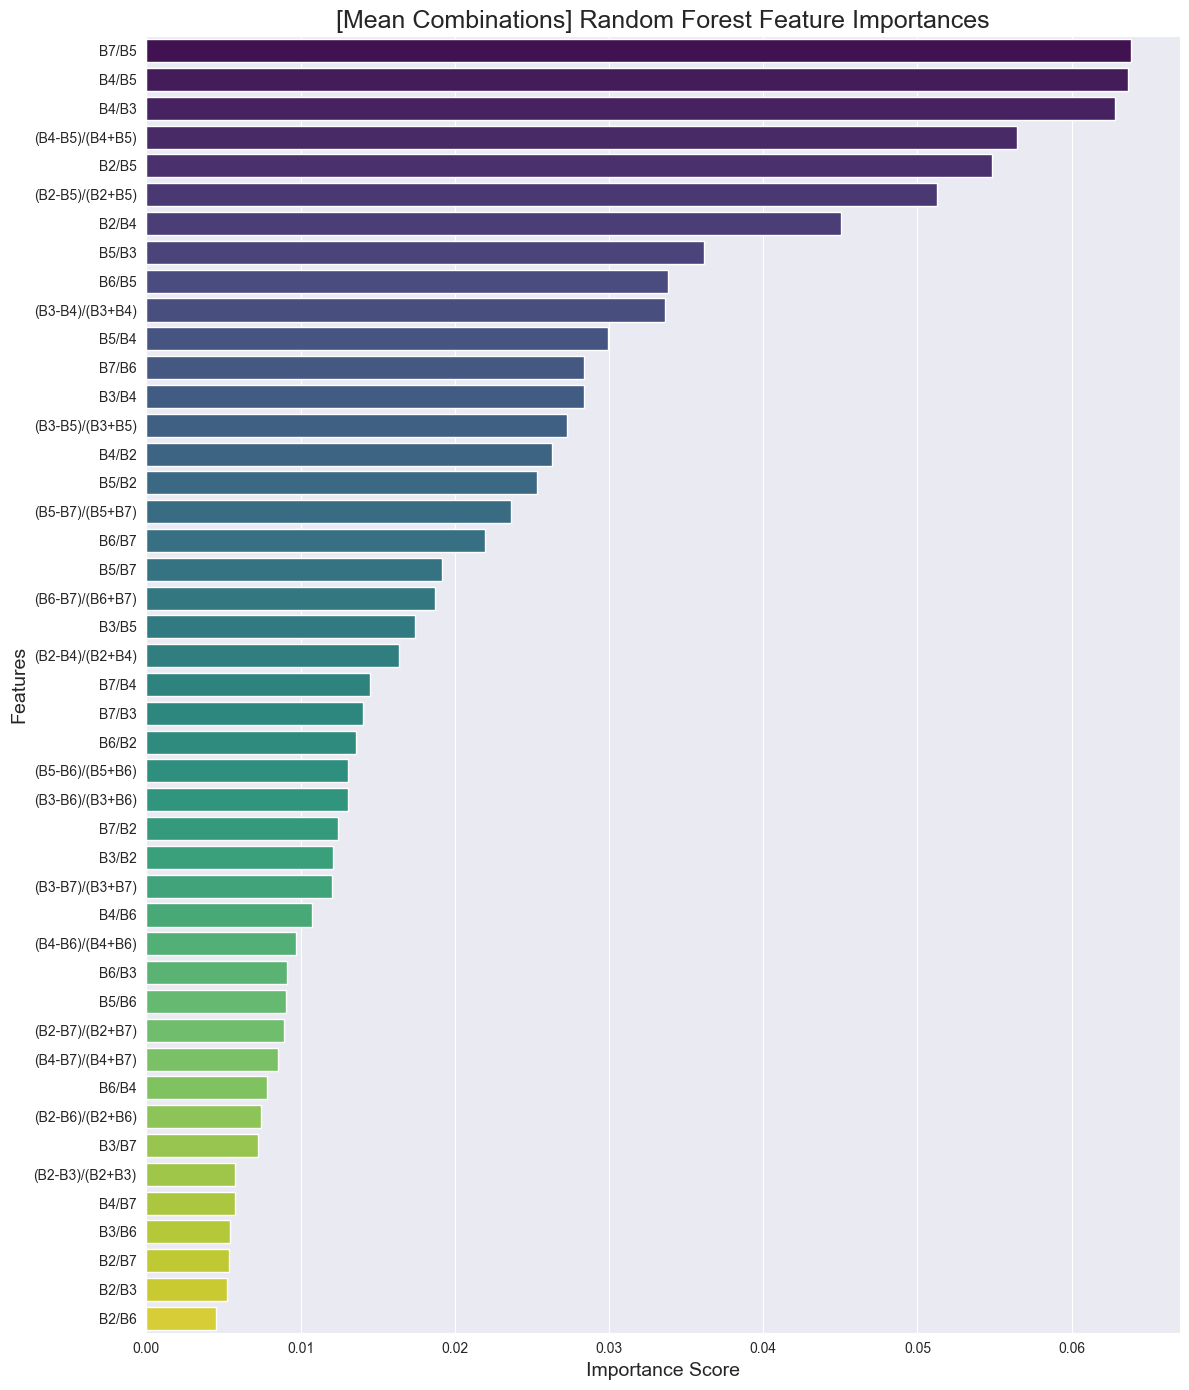

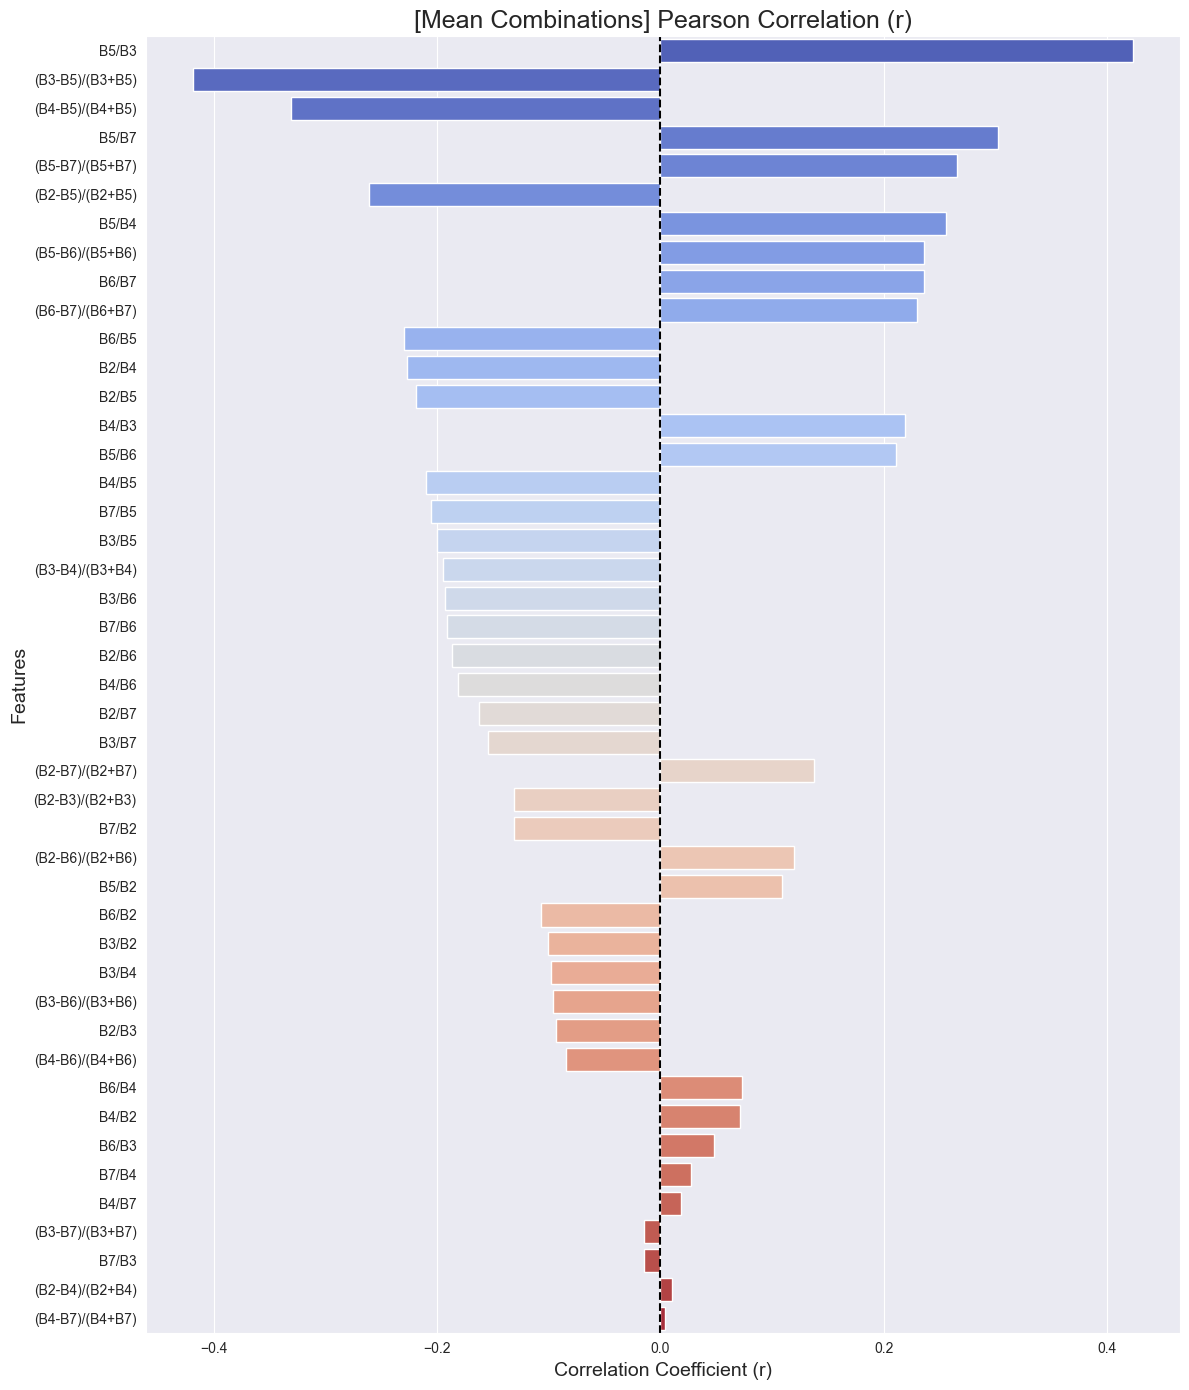

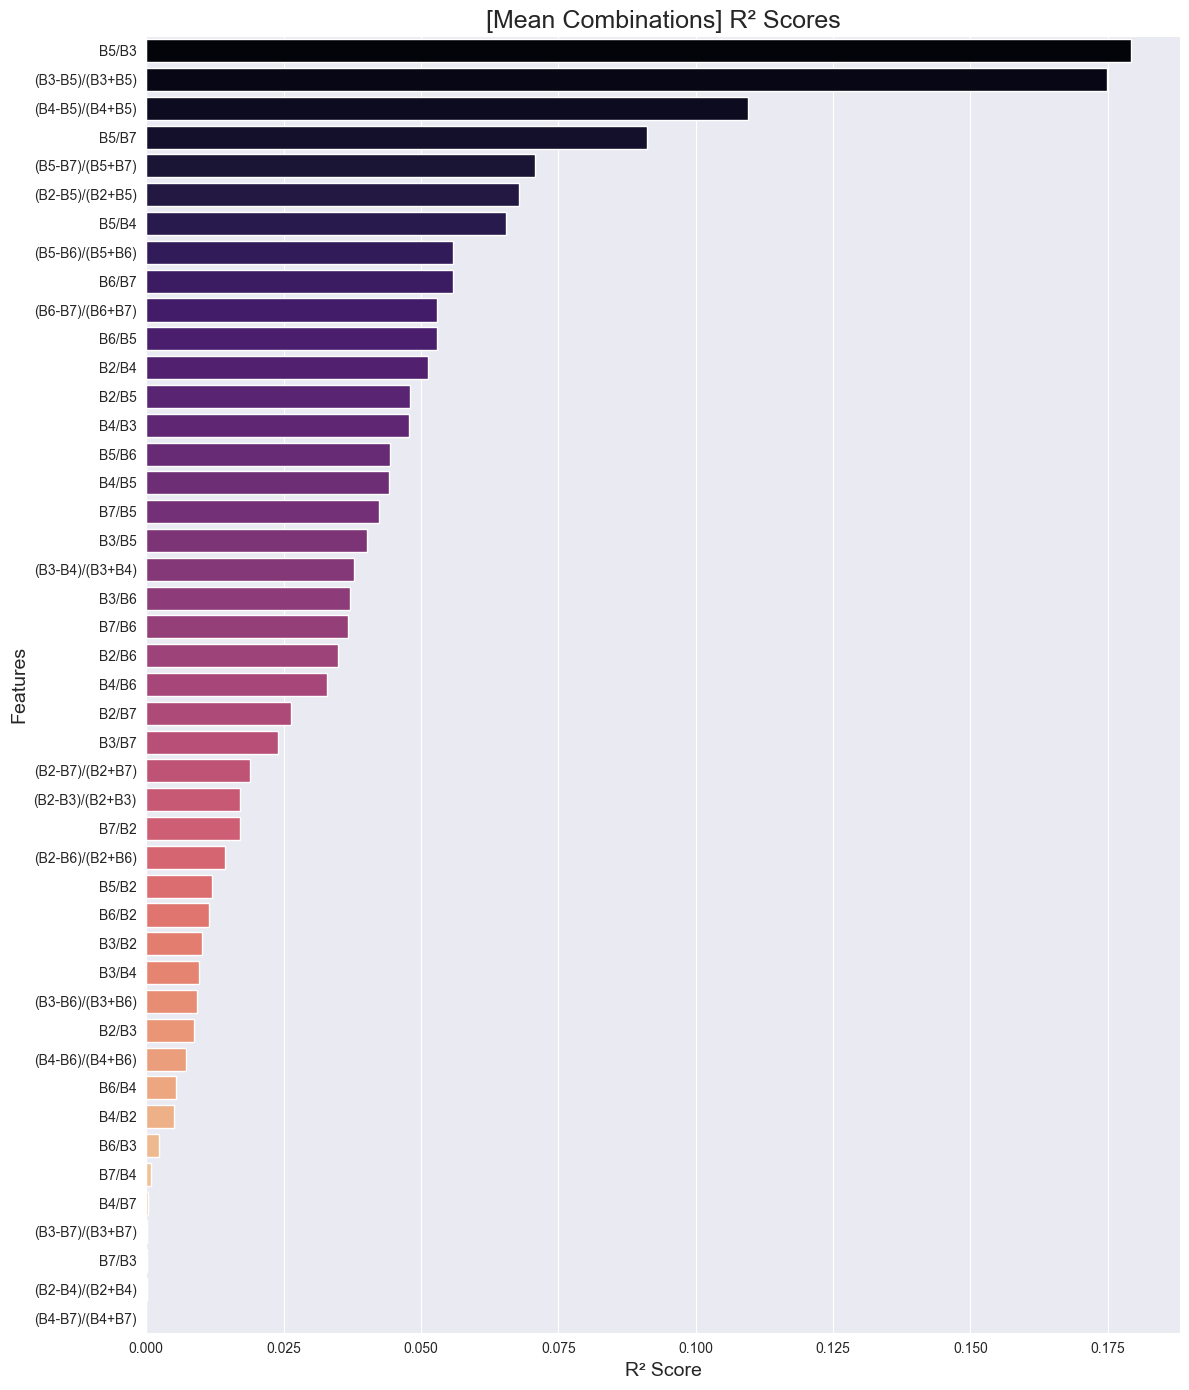

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# --- 1. Load Data ---
file_path = "Landsat89_2024_Combinations 2(Mean_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
start_idx = df.columns.get_loc('B2/B3')
end_idx = df.columns.get_loc('(B6-B7)/(B6+B7)') + 1
feature_cols = df.columns[start_idx:end_idx]

data = df[[target_col] + list(feature_cols)].dropna()
X = data[feature_cols]
y = data[target_col]

# --- 3. Calculate Metrics ---
# Random Forest Importance
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = rf.feature_importances_

# Pearson Correlation and R2 Score
correlations = X.apply(lambda col: col.corr(y))
r2_scores = correlations ** 2

# Combine into one DataFrame and sort by R2 Score
results_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': importances,
    'Correlation (r)': correlations,
    'R2_Score': r2_scores
}).sort_values(by='R2_Score', ascending=False)

# Print the complete list of values
print("==========================================================")
print("     [Mean] Complete Feature Metrics (Sorted by R2)       ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting (Separate, Full Width) ---

# Plot 1: Random Forest Feature Importance
plt.figure(figsize=(12, 14))
rf_sorted = results_df.sort_values(by='RF_Importance', ascending=False)
sns.barplot(x='RF_Importance', y='Feature', data=rf_sorted, palette='viridis', hue='Feature', legend=False)
plt.title('[Mean Combinations] Random Forest Feature Importances', fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Pearson Correlation
plt.figure(figsize=(12, 14))
corr_sorted = results_df.sort_values(by='Correlation (r)', key=abs, ascending=False)
sns.barplot(x='Correlation (r)', y='Feature', data=corr_sorted, palette='coolwarm', hue='Feature', legend=False)
plt.title('[Mean Combinations] Pearson Correlation (r)', fontsize=18)
plt.xlabel('Correlation Coefficient (r)', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Plot 3: R2 Score
plt.figure(figsize=(12, 14))
r2_sorted = results_df.sort_values(by='R2_Score', ascending=False)
sns.barplot(x='R2_Score', y='Feature', data=r2_sorted, palette='magma', hue='Feature', legend=False)
plt.title('[Mean Combinations] R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# for median

    [Median] Complete Feature Metrics (Sorted by R2)      
        Feature  RF_Importance  Correlation (r)  R2_Score
          B5/B3       0.043052         0.430268  0.185131
(B3-B5)/(B3+B5)       0.032442        -0.421519  0.177679
(B4-B5)/(B4+B5)       0.068199        -0.338154  0.114348
          B5/B7       0.023374         0.286822  0.082267
(B5-B7)/(B5+B7)       0.029068         0.258830  0.066993
          B5/B4       0.032342         0.251098  0.063050
          B6/B7       0.007204         0.234620  0.055047
(B6-B7)/(B6+B7)       0.006811         0.231861  0.053759
          B2/B4       0.048180        -0.219257  0.048074
(B2-B5)/(B2+B5)       0.101640        -0.215115  0.046274
          B4/B3       0.046209         0.214691  0.046092
          B3/B6       0.015257        -0.201827  0.040734
          B7/B6       0.014982        -0.200527  0.040211
          B5/B6       0.022257         0.198802  0.039522
          B2/B6       0.005955        -0.194845  0.037964
          B4/

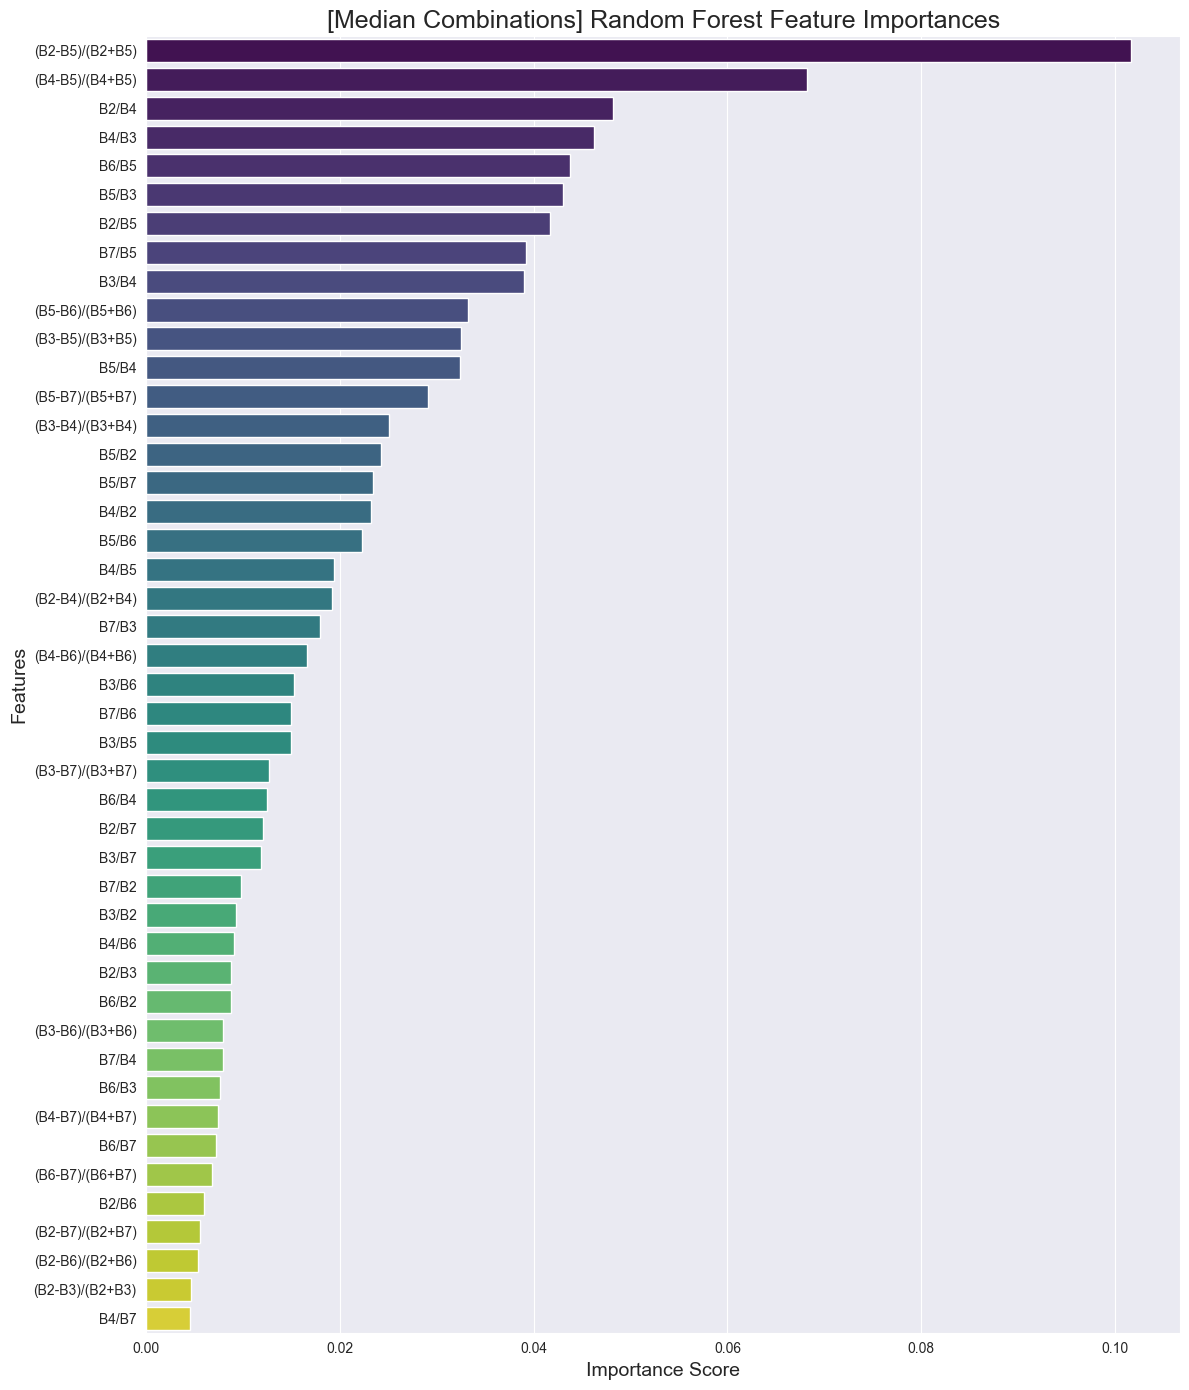

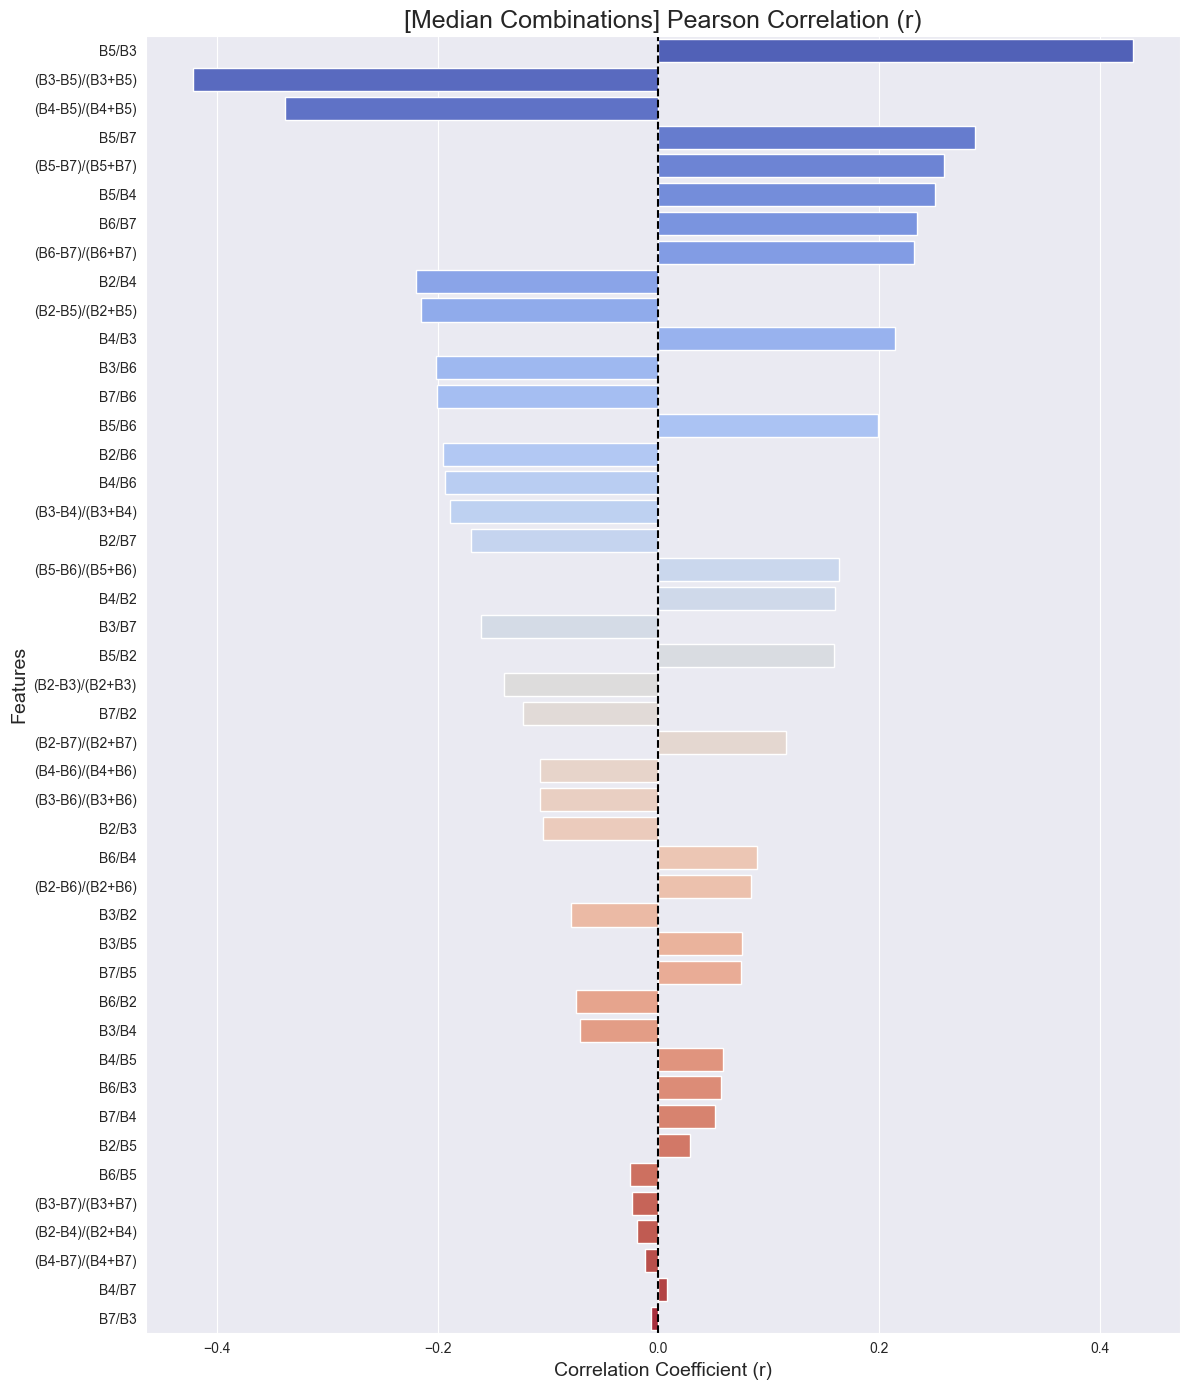

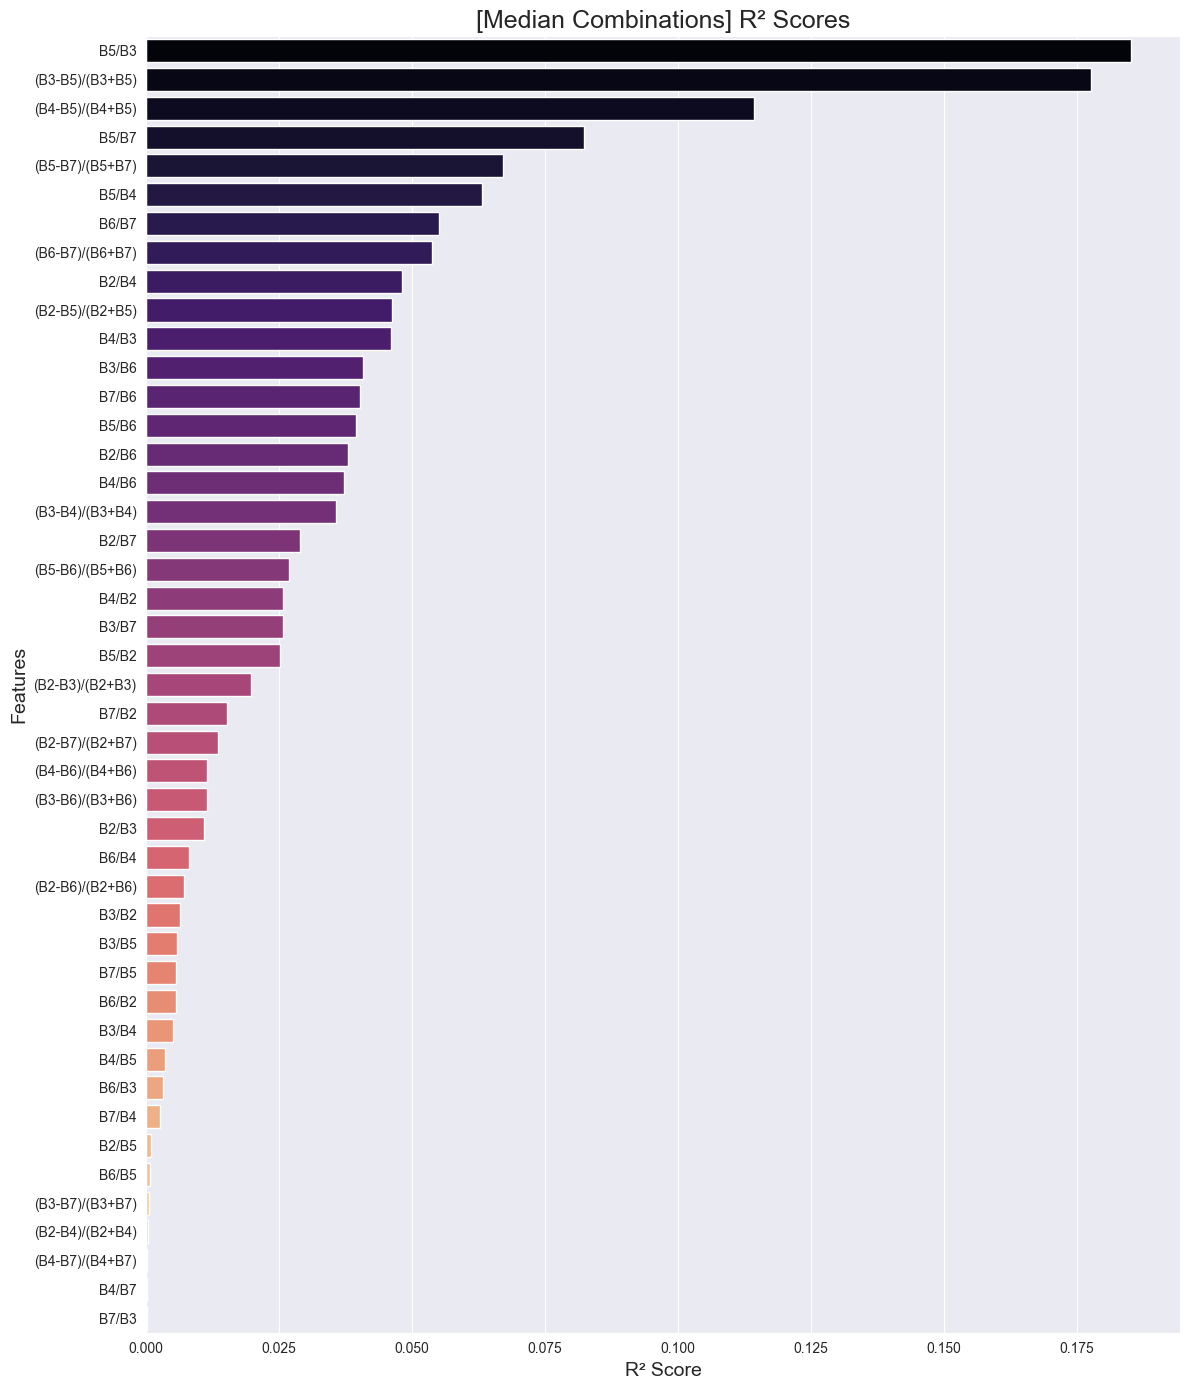

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# --- 1. Load Data ---
file_path = "Landsat89_2024_Combinations 2(Median_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
start_idx = df.columns.get_loc('B2/B3')
end_idx = df.columns.get_loc('(B6-B7)/(B6+B7)') + 1
feature_cols = df.columns[start_idx:end_idx]

data = df[[target_col] + list(feature_cols)].dropna()
X = data[feature_cols]
y = data[target_col]

# --- 3. Calculate Metrics ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = rf.feature_importances_

correlations = X.apply(lambda col: col.corr(y))
r2_scores = correlations ** 2

results_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': importances,
    'Correlation (r)': correlations,
    'R2_Score': r2_scores
}).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("    [Median] Complete Feature Metrics (Sorted by R2)      ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting (Separate, Full Width) ---

# Plot 1: RF Importance
plt.figure(figsize=(12, 14))
rf_sorted = results_df.sort_values(by='RF_Importance', ascending=False)
sns.barplot(x='RF_Importance', y='Feature', data=rf_sorted, palette='viridis', hue='Feature', legend=False)
plt.title('[Median Combinations] Random Forest Feature Importances', fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Correlation
plt.figure(figsize=(12, 14))
corr_sorted = results_df.sort_values(by='Correlation (r)', key=abs, ascending=False)
sns.barplot(x='Correlation (r)', y='Feature', data=corr_sorted, palette='coolwarm', hue='Feature', legend=False)
plt.title('[Median Combinations] Pearson Correlation (r)', fontsize=18)
plt.xlabel('Correlation Coefficient (r)', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Plot 3: R2 Score
plt.figure(figsize=(12, 14))
r2_sorted = results_df.sort_values(by='R2_Score', ascending=False)
sns.barplot(x='R2_Score', y='Feature', data=r2_sorted, palette='magma', hue='Feature', legend=False)
plt.title('[Median Combinations] R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# for sd file

      [SD] Complete Feature Metrics (Sorted by R2)        
        Feature  RF_Importance  Correlation (r)     R2_Score
          B7/B6       0.043278         0.187184 3.503781e-02
          B5/B2       0.030561         0.174695 3.051851e-02
          B3/B7       0.028724        -0.161326 2.602621e-02
          B2/B4       0.022861        -0.157634 2.484846e-02
(B3-B4)/(B3+B4)       0.037526        -0.155760 2.426116e-02
          B3/B6       0.012378        -0.152863 2.336712e-02
          B2/B6       0.023947        -0.147568 2.177628e-02
(B2-B5)/(B2+B5)       0.026845        -0.142640 2.034629e-02
(B2-B4)/(B2+B4)       0.017525        -0.132004 1.742514e-02
          B2/B7       0.012141        -0.131698 1.734444e-02
          B7/B2       0.008170         0.129541 1.678087e-02
          B4/B7       0.017568        -0.126851 1.609123e-02
(B2-B7)/(B2+B7)       0.011152        -0.125096 1.564890e-02
          B3/B5       0.021904        -0.112587 1.267579e-02
          B6/B5       0.01

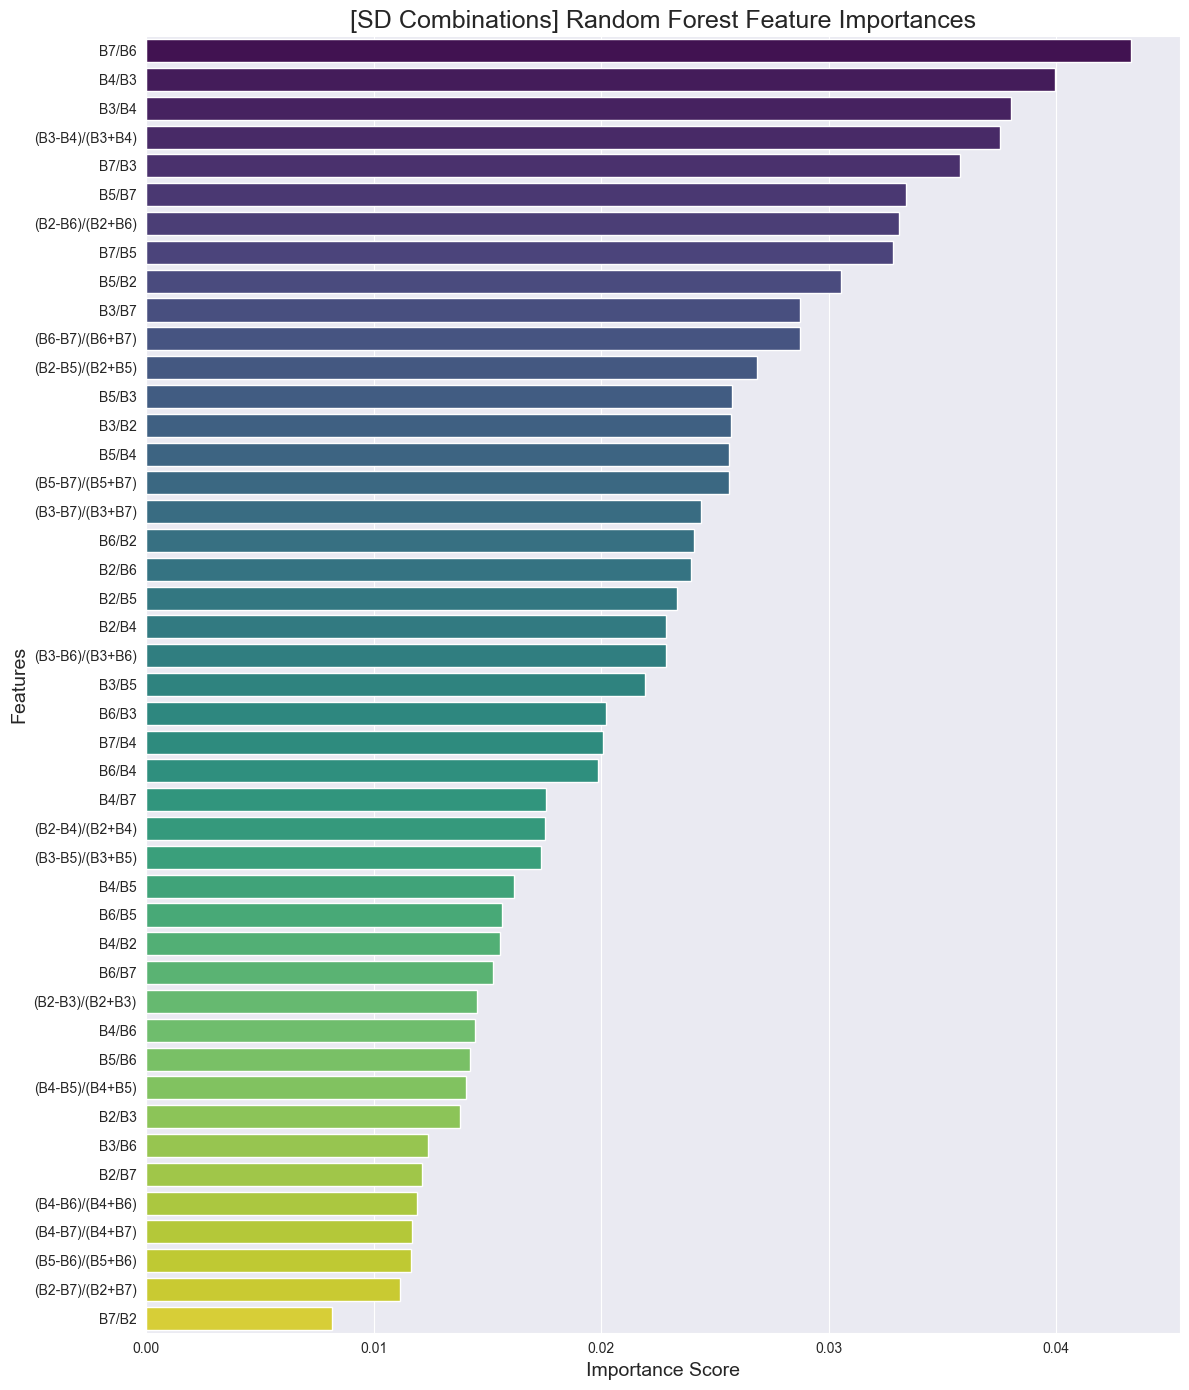

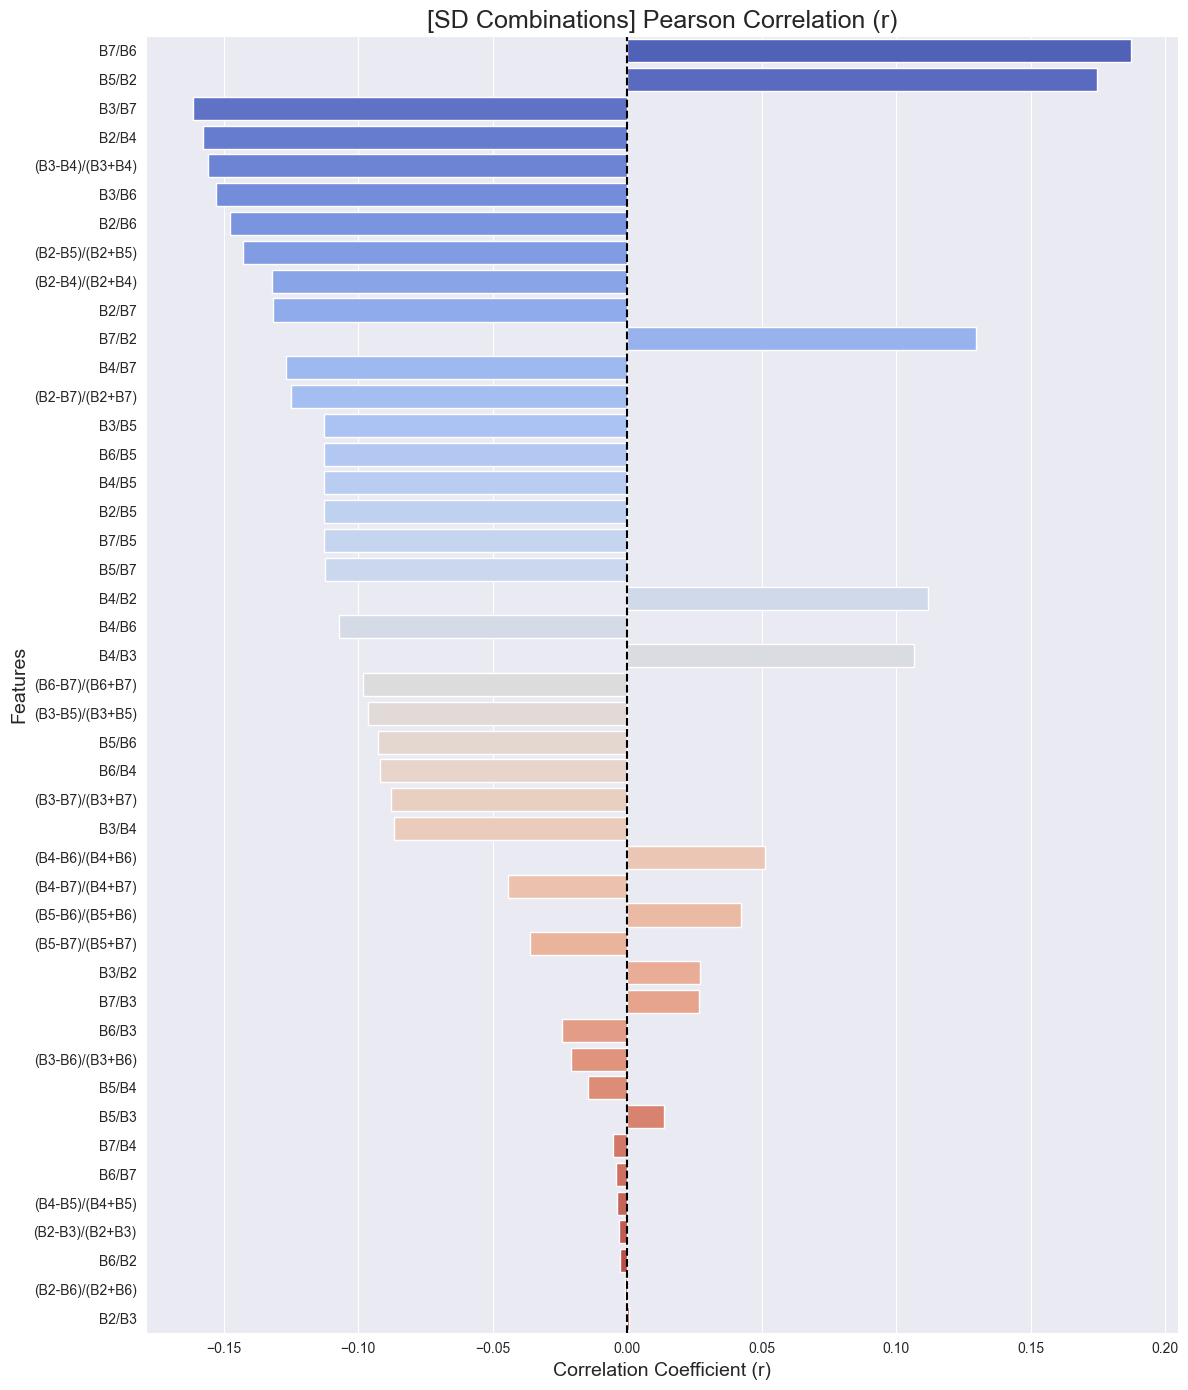

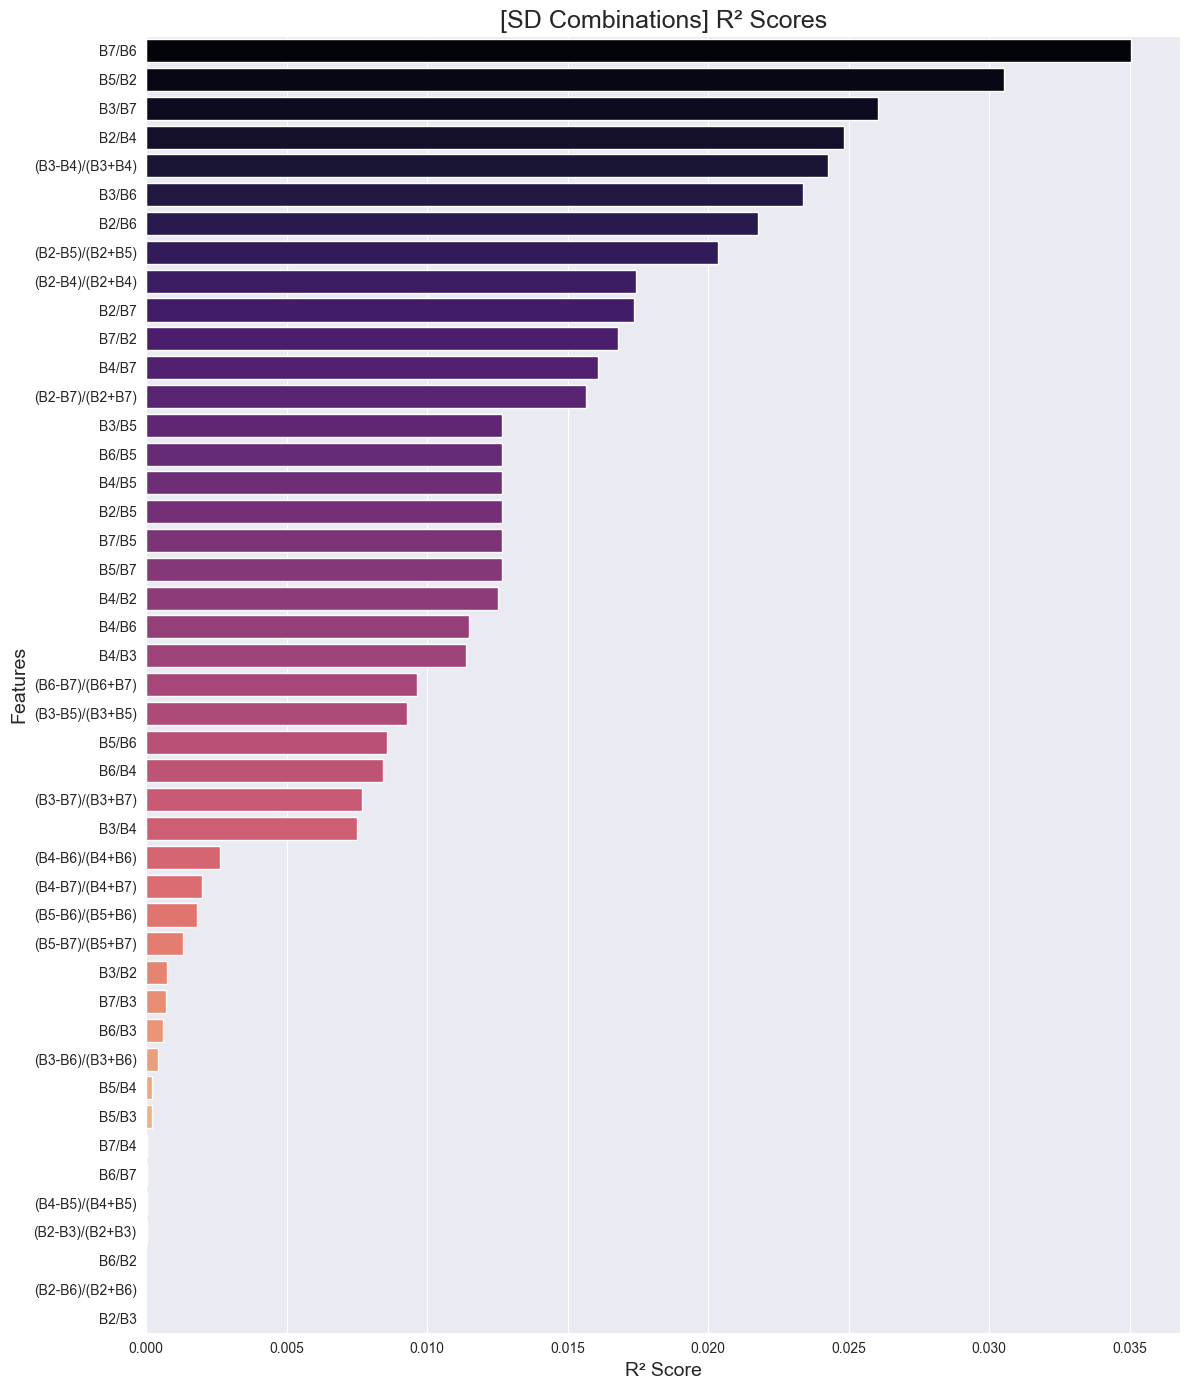

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

# --- 1. Load Data ---
file_path = "Landsat89_2024_Combinations 2(SD_Combinations).csv"
df = pd.read_csv(file_path, encoding='cp1252')

# --- 2. Features and Target ---
target_col = 'Target Variable(Chlorophyll-a)'
start_idx = df.columns.get_loc('B2/B3')
end_idx = df.columns.get_loc('(B6-B7)/(B6+B7)') + 1
feature_cols = df.columns[start_idx:end_idx]

data = df[[target_col] + list(feature_cols)].dropna()
X = data[feature_cols]
y = data[target_col]

# --- 3. Calculate Metrics ---
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = rf.feature_importances_

correlations = X.apply(lambda col: col.corr(y))
r2_scores = correlations ** 2

results_df = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': importances,
    'Correlation (r)': correlations,
    'R2_Score': r2_scores
}).sort_values(by='R2_Score', ascending=False)

print("==========================================================")
print("      [SD] Complete Feature Metrics (Sorted by R2)        ")
print("==========================================================")
print(results_df.to_string(index=False))
print("\n")

# --- 4. Plotting (Separate, Full Width) ---

# Plot 1: RF Importance
plt.figure(figsize=(12, 14))
rf_sorted = results_df.sort_values(by='RF_Importance', ascending=False)
sns.barplot(x='RF_Importance', y='Feature', data=rf_sorted, palette='viridis', hue='Feature', legend=False)
plt.title('[SD Combinations] Random Forest Feature Importances', fontsize=18)
plt.xlabel('Importance Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()

# Plot 2: Correlation
plt.figure(figsize=(12, 14))
corr_sorted = results_df.sort_values(by='Correlation (r)', key=abs, ascending=False)
sns.barplot(x='Correlation (r)', y='Feature', data=corr_sorted, palette='coolwarm', hue='Feature', legend=False)
plt.title('[SD Combinations] Pearson Correlation (r)', fontsize=18)
plt.xlabel('Correlation Coefficient (r)', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()

# Plot 3: R2 Score
plt.figure(figsize=(12, 14))
r2_sorted = results_df.sort_values(by='R2_Score', ascending=False)
sns.barplot(x='R2_Score', y='Feature', data=r2_sorted, palette='magma', hue='Feature', legend=False)
plt.title('[SD Combinations] R² Scores', fontsize=18)
plt.xlabel('R² Score', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.tight_layout()
plt.show()